# QC: Full-Resolution Inference (3-Class LITHO_FLUMY_AV)

This notebook evaluates full-resolution inference using the 3-class lithology scheme:
- 0 Shale
- 1 Sand
- 2 Silt

Model run used in this notebook:
`/mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260811_153252`

Matching training results:
`/mnt/sda_data/tharitt/diffsim/results/case1_flumy_conditional/20260811_153252`

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import torch
from tqdm import tqdm

repo_root = Path.cwd().resolve()
if not (repo_root / 'diffsim').exists():
    candidate = repo_root.parent
    if (candidate / 'diffsim').exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from diffsim.core.network import Network
from diffsim.core.inference import inference_full_resolution

print('repo_root =', repo_root)

/mnt/sda_data/tharitt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo_root = /home/tharitt/working/DiffSim


In [2]:
# Paths and settings
RUN_TIMESTAMP = '20260818_102941' # kind of good
#RUN_TIMESTAMP = '20260817_094530'
#RUN_TIMESTAMP = '20260814_135226'
MODEL_DIR = Path('/mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional') / RUN_TIMESTAMP
RESULTS_DIR = Path('/mnt/sda_data/tharitt/diffsim/results/case1_flumy_conditional') / RUN_TIMESTAMP
CONFIG_PATH = MODEL_DIR / 'config.json'
RMS_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/flumy_dataset/test/rms')

# Optional GT facies directory for quantitative QC (matching file names)
GT_FACIES_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/flumy_dataset/test/facies')

if not MODEL_DIR.is_dir():
    raise FileNotFoundError(f'Model run directory not found: {MODEL_DIR}')
if not RESULTS_DIR.is_dir():
    raise FileNotFoundError(f'Results run directory not found: {RESULTS_DIR}')
if not CONFIG_PATH.is_file():
    raise FileNotFoundError(f'Model config not found: {CONFIG_PATH}')

CHECKPOINT_PATH = MODEL_DIR / 'best_model.pth'
if not CHECKPOINT_PATH.exists():
    candidates = sorted(MODEL_DIR.glob('checkpoint_epoch_*.pth'))
    if not candidates:
        raise FileNotFoundError(f'No checkpoint found in {MODEL_DIR}')
    CHECKPOINT_PATH = candidates[-1]

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SAMPLES = 16
DDIM_STEPS = 60
ETA = 0.3
MAX_FILES = 12
N_CLASSES = 3

FACIES_NAMES = {
    0: 'Shale',
    1: 'Sand',
    2: 'Silt',
}
FACIES_COLORS = {
    0: '#3E3E3E',
    1: '#E6B422',
    2: '#8FBBD9',
}

cmap6 = mcolors.ListedColormap([FACIES_COLORS[i] for i in range(N_CLASSES)])
norm6 = mcolors.BoundaryNorm(np.arange(-0.5, N_CLASSES + 0.5, 1), cmap6.N)

print('RUN_TIMESTAMP  :', RUN_TIMESTAMP)
print('CONFIG_PATH    :', CONFIG_PATH)
print('CHECKPOINT_PATH:', CHECKPOINT_PATH)
print('RESULTS_DIR    :', RESULTS_DIR)
print('RMS_DIR        :', RMS_DIR)
print('DEVICE         :', DEVICE)

RUN_TIMESTAMP  : 20260818_102941
CONFIG_PATH    : /mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260818_102941/config.json
CHECKPOINT_PATH: /mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260818_102941/best_model.pth
RESULTS_DIR    : /mnt/sda_data/tharitt/diffsim/results/case1_flumy_conditional/20260818_102941
RMS_DIR        : /mnt/sda_data/tharitt/diffsim/data/flumy_dataset/test/rms
DEVICE         : cuda


In [3]:
def load_model(config_path: Path, checkpoint_path: Path, device: str):
    with open(config_path) as f:
        config = json.load(f)

    cond = config['conditional']
    unet_config = {
        'image_size': config['image_size'],
        'in_channel': cond['in_channel'],
        'out_channel': cond['out_channel'],
        'inner_channel': cond['inner_channel'],
        'channel_mults': cond['channel_mults'],
        'attn_res': cond['attn_res'],
        'res_blocks': cond['res_blocks'],
        'dropout': 0.0,
    }

    network = Network(
        unet=unet_config,
        beta_schedule=cond['beta_schedule'],
        module_name=cond.get('module_name', 'guided_diffusion'),
        predict_type=cond.get('predict_type', 'epsilon'),
    )

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    state = ckpt['model_state'] if isinstance(ckpt, dict) and 'model_state' in ckpt else ckpt

    # Checkpoints may contain precomputed schedule buffers not present until set_new_noise_schedule is called.
    incompatible = network.load_state_dict(state, strict=False)
    if incompatible.missing_keys:
        print('Missing keys:', incompatible.missing_keys)
    if incompatible.unexpected_keys:
        print('Unexpected keys (ignored):', incompatible.unexpected_keys)

    network.to(device)
    network.eval()
    return network

network = load_model(CONFIG_PATH, CHECKPOINT_PATH, DEVICE)
print('Model loaded.')

Unexpected keys (ignored): ['gammas', 'sqrt_recip_gammas', 'sqrt_recipm1_gammas', 'posterior_log_variance_clipped', 'posterior_mean_coef1', 'posterior_mean_coef2']
Model loaded.


## QC 5: Low/Mid/High NG × Low/Mid/High ISBX

This section selects representative `(ng, isbx)` combinations directly from available full-resolution cubes,
runs inference on a common depth slice for each case, and visualizes:
1. RMS input
2. Most-likely facies prediction
3. Ground-truth facies (reclassified + windowed mode)


In [8]:
from diffsim.data.style_match import build_reference_cdf, histogram_match_rms, load_seismic_rms_grid

# The model was trained on data/slice_data_2d, whose RMS crops were histogram-matched
# to the real seismic RMS reference (h05_sub1). Raw flumy3d RMS cubes are NOT in that
# distribution, so they must go through the same matching before inference.
H05_PATH = repo_root / 'style-matching' / 'h05_sub1'
STYLE_CLIP_PCT = 99.5

ref_grid = load_seismic_rms_grid(H05_PATH)
ref_sorted_vals = build_reference_cdf(ref_grid, clip_percentile=STYLE_CLIP_PCT)
del ref_grid

print(f'Reference RMS range (clipped @{STYLE_CLIP_PCT}%): '
      f'{ref_sorted_vals[0]:.2f} - {ref_sorted_vals[-1]:.2f}')


Reference RMS range (clipped @99.5%): 0.00 - 1188.94


Selected ng levels   : [30, 40, 50, 60]
Selected isbx levels : [np.int64(20), np.int64(90), np.int64(160)]


,stem,ng,isbx,seed
0,ng30_isbx20_seed8,30,20,8
1,ng30_isbx90_seed8,30,90,8
2,ng30_isbx160_seed8,30,160,8
3,ng40_isbx20_seed8,40,20,8
4,ng40_isbx90_seed8,40,90,8
5,ng40_isbx160_seed8,40,160,8
6,ng50_isbx20_seed8,50,20,8
7,ng50_isbx90_seed8,50,90,8
8,ng50_isbx160_seed8,50,160,8
9,ng60_isbx20_seed8,60,20,8


Multi-inference: 100%|██████████| 8/8 [00:09<00:00,  1.24s/it]


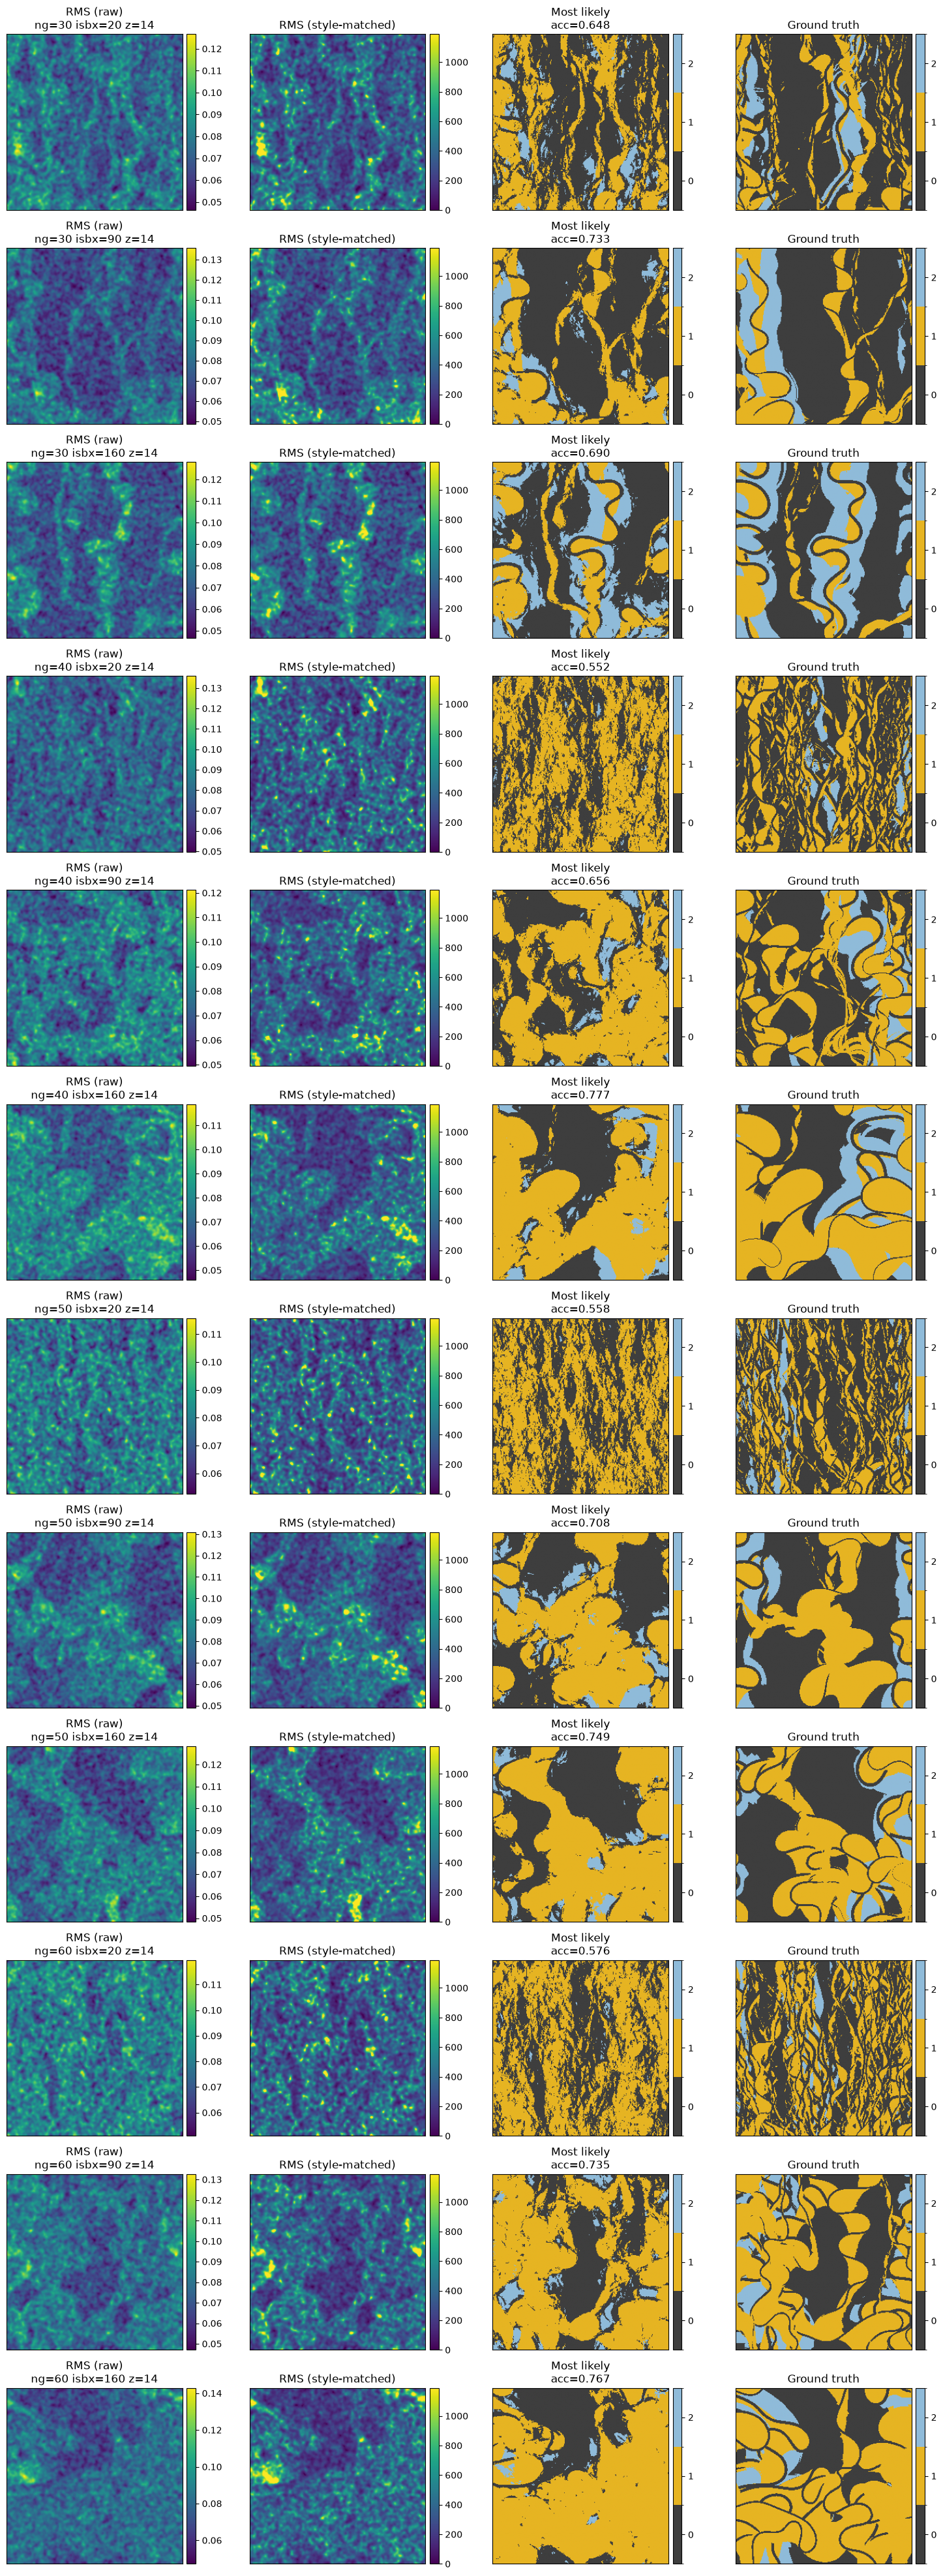

QC metrics for NG×ISBX grid:


,stem,ng,isbx,seed,z,pixel_acc,mean_max_prob,mean_entropy
0,ng30_isbx20_seed8,30,20,8,14,0.647629,0.658298,0.702602
1,ng30_isbx90_seed8,30,90,8,14,0.732681,0.729080,0.578543
2,ng30_isbx160_seed8,30,160,8,14,0.689743,0.707668,0.585753
3,ng40_isbx20_seed8,40,20,8,14,0.552155,0.663689,0.677296
4,ng40_isbx90_seed8,40,90,8,14,0.656387,0.725029,0.589309
5,ng40_isbx160_seed8,40,160,8,14,0.777298,0.795498,0.453603
6,ng50_isbx20_seed8,50,20,8,14,0.558304,0.672731,0.637105
7,ng50_isbx90_seed8,50,90,8,14,0.708481,0.737602,0.560723
8,ng50_isbx160_seed8,50,160,8,14,0.748734,0.788738,0.464685
9,ng60_isbx20_seed8,60,20,8,14,0.575943,0.675875,0.646609


In [10]:
import re
from diffsim.data.flumy_generator import FlumyGenerator, map_channelasso_to_litho
from diffsim.data.seismic import compute_facies_mode_window

FULL_RMS_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/flumy3d/rms')
FULL_FACIES_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/flumy3d/facies')
RMS_WINDOW_HALF = 2
GRID_N_SAMPLES = 8
GRID_DDIM_STEPS = 100
GRID_ETA = 0.1

pattern = re.compile(r'ng(?P<ng>\d+)_isbx(?P<isbx>\d+)_seed(?P<seed>\d+)')

catalog = []
for p in sorted(FULL_RMS_DIR.glob('*.npy')):
    m = pattern.fullmatch(p.stem)
    if not m:
        continue
    facies_path = FULL_FACIES_DIR / p.name
    if not facies_path.exists():
        continue
    catalog.append({
        'stem': p.stem,
        'rms_path': p,
        'facies_path': facies_path,
        'ng': int(m.group('ng')),
        'isbx': int(m.group('isbx')),
        'seed': int(m.group('seed')),
    })

if not catalog:
    raise RuntimeError(f'No matching cubes found under {FULL_RMS_DIR} and {FULL_FACIES_DIR}')

cat_df = pd.DataFrame(catalog).sort_values(['ng', 'isbx', 'seed']).reset_index(drop=True)

ng_values = sorted(cat_df['ng'].unique())
isbx_values = sorted(cat_df['isbx'].unique())

if len(ng_values) < 3 or len(isbx_values) < 3:
    raise RuntimeError(
        f'Need at least 3 unique ng and isbx values, got ng={ng_values}, isbx={isbx_values}'
    )

# Pick representative low/mid/high by sorted index
#ng_levels = [ng_values[0], ng_values[len(ng_values)//2], ng_values[-1]]
ng_levels = [ 30, 40, 50, 60]
isbx_levels = [isbx_values[0], isbx_values[len(isbx_values)//2], isbx_values[-1]]

print('Selected ng levels   :', ng_levels)
print('Selected isbx levels :', isbx_levels)

selected_cases = []
for ng in ng_levels:
    for isbx in isbx_levels:
        sub = cat_df[(cat_df['ng'] == ng) & (cat_df['isbx'] == isbx)]
        if len(sub) == 0:
            continue
        # choose median seed for stability
        case = sub.iloc[len(sub)//2].to_dict()
        selected_cases.append(case)

if len(selected_cases) == 0:
    raise RuntimeError('No (ng, isbx) combinations selected')

selected_df = pd.DataFrame(selected_cases).sort_values(['ng', 'isbx']).reset_index(drop=True)
display(selected_df[['stem', 'ng', 'isbx', 'seed']])

# Run inference and visualize RMS / prediction / GT
n_rows = len(selected_df)
fig, axes = plt.subplots(n_rows, 4, figsize=(15, 3.3 * n_rows), squeeze=False)

records = []
for i, row in selected_df.iterrows():
    rms_3d = np.load(row['rms_path'])
    facies_raw_3d = np.load(row['facies_path'])

    facies_6_3d = FlumyGenerator.reclassify_facies(facies_raw_3d)
    facies_mode_3d = compute_facies_mode_window(facies_6_3d, RMS_WINDOW_HALF)
    facies_mode_3d = map_channelasso_to_litho(facies_mode_3d)

    nz = min(rms_3d.shape[2], facies_mode_3d.shape[2])
    z = nz // 2

    rms_2d_raw = rms_3d[:, :, z]
    # Match amplitude distribution to the real seismic reference (same as training pipeline)
    rms_2d = histogram_match_rms(rms_2d_raw, ref_sorted_vals)
    gt_2d = facies_mode_3d[:, :, z]

    probs, samples, pred_2d = inference_full_resolution(
        network,
        rms_2d,
        n_samples=GRID_N_SAMPLES,
        ddim_steps=GRID_DDIM_STEPS,
        eta=GRID_ETA,
        device=DEVICE,
    )

    prob_stack = np.stack([probs[k] for k in range(N_CLASSES)], axis=-1)
    max_prob = prob_stack.max(axis=-1)
    entropy = -(prob_stack * np.log(prob_stack + 1e-8)).sum(axis=-1)

    pixel_acc = float((pred_2d == gt_2d).mean())
    records.append({
        'stem': row['stem'],
        'ng': row['ng'],
        'isbx': row['isbx'],
        'seed': row['seed'],
        'z': int(z),
        'pixel_acc': pixel_acc,
        'mean_max_prob': float(max_prob.mean()),
        'mean_entropy': float(entropy.mean()),
    })

    ax0, ax1 = axes[i, 0], axes[i, 1]
    im0 = ax0.imshow(rms_2d_raw, origin='lower', cmap='viridis')
    ax0.set_title(f"RMS (raw)\nng={row['ng']} isbx={row['isbx']} z={z}")
    plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.02)

    im0b = ax1.imshow(rms_2d, origin='lower', cmap='viridis')
    ax1.set_title("RMS (style-matched)")
    plt.colorbar(im0b, ax=ax1, fraction=0.046, pad=0.02)

    ax2, ax3 = axes[i, 2], axes[i, 3]
    im1 = ax2.imshow(pred_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax2.set_title(f"Most likely\nacc={pixel_acc:.3f}")
    plt.colorbar(im1, ax=ax2, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

    im2 = ax3.imshow(gt_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax3.set_title("Ground truth")
    plt.colorbar(im2, ax=ax3, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

    for a in (ax0, ax1, ax2, ax3):
        a.set_xticks([])
        a.set_yticks([])

plt.tight_layout()
plt.show()

qc_grid_df = pd.DataFrame(records).sort_values(['ng', 'isbx']).reset_index(drop=True)
print('QC metrics for NG×ISBX grid:')
display(qc_grid_df)


## QC 6: DDIM Steps Sensitivity

Sweep `GRID_DDIM_STEPS` from 100 to 1000 (step 200) on 3 test slices with varying net-to-gross.
Visualizes how sampling quality and pixel accuracy change with the number of DDIM steps.

DDIM steps to test: [30, 60, 90, 150, 300]
Test cases (ng): [50]
  ddim_steps=30, ng=50 ... 

Multi-inference: 100%|██████████| 8/8 [00:03<00:00,  2.64it/s]

acc=0.701
  ddim_steps=60, ng=50 ... 


Multi-inference: 100%|██████████| 8/8 [00:06<00:00,  1.33it/s]

acc=0.701
  ddim_steps=90, ng=50 ... 

...

Multi-inference: 100%|██████████| 8/8 [00:15<00:00,  1.91s/it]

acc=0.685
  ddim_steps=300, ng=50 ... 


Multi-inference: 100%|██████████| 8/8 [00:30<00:00,  3.81s/it]

acc=0.697


,ddim_steps,ng,stem,pixel_acc,mean_entropy
0,30,50,ng50_isbx90_seed8,0.700577,0.523502
1,60,50,ng50_isbx90_seed8,0.700500,0.553884
2,90,50,ng50_isbx90_seed8,0.714508,0.556387
3,150,50,ng50_isbx90_seed8,0.685425,0.576035
4,300,50,ng50_isbx90_seed8,0.696899,0.591217


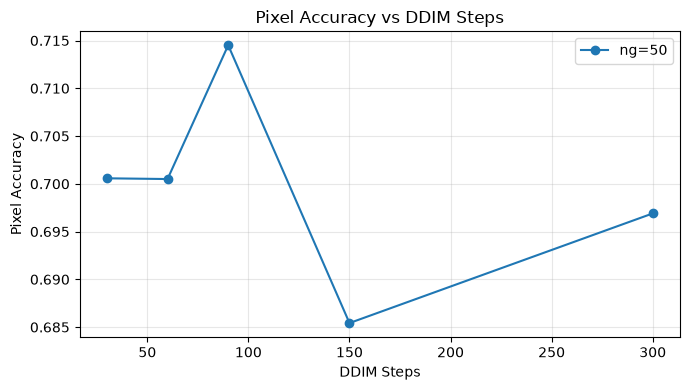

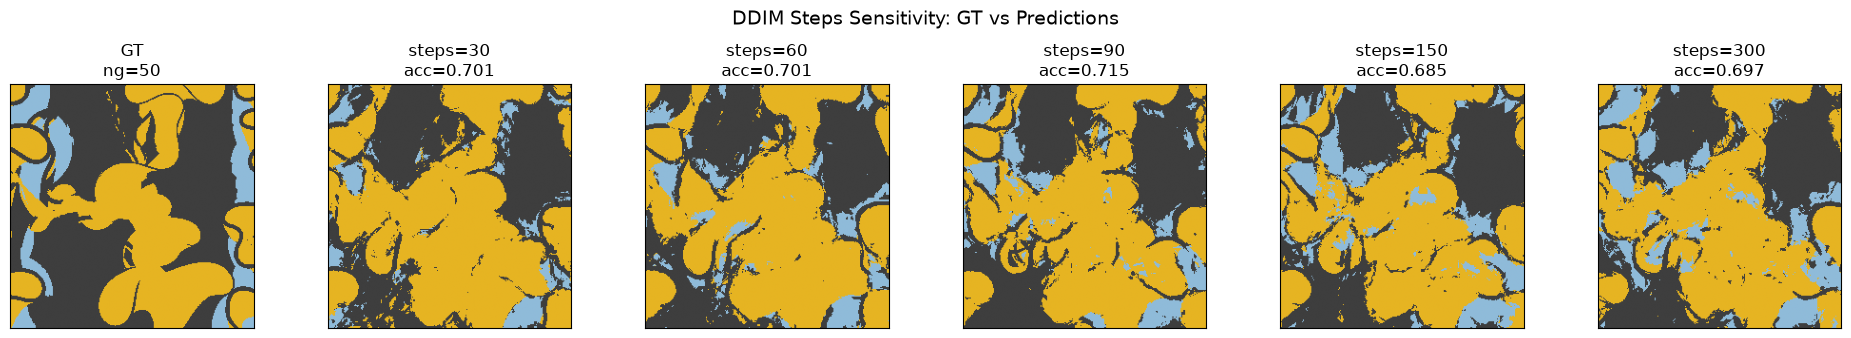

In [11]:
#DDIM_STEPS_SWEEP = list(range(100, 1001, 200))  # [100, 300, 500, 700, 900]
DDIM_STEPS_SWEEP = [30, 60, 90, 150, 300]
SWEEP_N_SAMPLES = 8
SWEEP_ETA = 0.3

# Pick 3 cases spanning low/mid/high net-to-gross
#sweep_ng_levels = [ng_values[0], ng_values[len(ng_values)//2], ng_values[-1]]
sweep_ng_levels = [50]
sweep_cases = []
for ng in sweep_ng_levels:
    sub = cat_df[cat_df['ng'] == ng]
    if len(sub) == 0:
        continue
    sweep_cases.append(sub.iloc[len(sub)//2].to_dict())

print(f'DDIM steps to test: {DDIM_STEPS_SWEEP}')
print(f'Test cases (ng): {[c["ng"] for c in sweep_cases]}')

# Pre-load data and compute ground truth
sweep_data = []
for case in sweep_cases:
    rms_3d = np.load(case['rms_path'])
    facies_raw_3d = np.load(case['facies_path'])
    facies_6_3d = FlumyGenerator.reclassify_facies(facies_raw_3d)
    facies_mode_3d = compute_facies_mode_window(facies_6_3d, RMS_WINDOW_HALF)
    facies_mode_3d = map_channelasso_to_litho(facies_mode_3d)
    nz = min(rms_3d.shape[2], facies_mode_3d.shape[2])
    z = nz // 2
    sweep_data.append({
        'stem': case['stem'],
        'ng': case['ng'],
        # Match amplitude distribution to the real seismic reference (same as training pipeline)
        'rms_2d': histogram_match_rms(rms_3d[:, :, z], ref_sorted_vals),
        'gt_2d': facies_mode_3d[:, :, z],
        'z': z,
    })

# Run sweep
sweep_records = []
sweep_preds = {}  # (case_idx, ddim_steps) -> pred_2d

for ddim_steps in DDIM_STEPS_SWEEP:
    for ci, sd in enumerate(sweep_data):
        print(f'  ddim_steps={ddim_steps}, ng={sd["ng"]} ...', end=' ', flush=True)
        probs, samples, pred_2d = inference_full_resolution(
            network,
            sd['rms_2d'],
            n_samples=SWEEP_N_SAMPLES,
            ddim_steps=ddim_steps,
            eta=SWEEP_ETA,
            device=DEVICE,
        )
        prob_stack = np.stack([probs[k] for k in range(N_CLASSES)], axis=-1)
        pixel_acc = float((pred_2d == sd['gt_2d']).mean())
        entropy = -(prob_stack * np.log(prob_stack + 1e-8)).sum(axis=-1)

        sweep_records.append({
            'ddim_steps': ddim_steps,
            'ng': sd['ng'],
            'stem': sd['stem'],
            'pixel_acc': pixel_acc,
            'mean_entropy': float(entropy.mean()),
        })
        sweep_preds[(ci, ddim_steps)] = pred_2d
        print(f'acc={pixel_acc:.3f}')

sweep_df = pd.DataFrame(sweep_records)
display(sweep_df)

# --- Plot 1: Accuracy vs DDIM steps ---
fig_acc, ax_acc = plt.subplots(1, 1, figsize=(7, 4))
for ng in sweep_ng_levels:
    sub = sweep_df[sweep_df['ng'] == ng]
    ax_acc.plot(sub['ddim_steps'], sub['pixel_acc'], 'o-', label=f'ng={ng}')
ax_acc.set_xlabel('DDIM Steps')
ax_acc.set_ylabel('Pixel Accuracy')
ax_acc.set_title('Pixel Accuracy vs DDIM Steps')
ax_acc.legend()
ax_acc.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Visual grid (cases × ddim_steps) ---
n_cases = len(sweep_data)
n_steps = len(DDIM_STEPS_SWEEP)
fig, axes = plt.subplots(n_cases, n_steps + 1, figsize=(3.2 * (n_steps + 1), 3.3 * n_cases), squeeze=False)

for ci, sd in enumerate(sweep_data):
    # Ground truth in first column
    im = axes[ci, 0].imshow(sd['gt_2d'], origin='lower', cmap=cmap6, norm=norm6)
    axes[ci, 0].set_title(f"GT\nng={sd['ng']}")
    axes[ci, 0].set_xticks([]); axes[ci, 0].set_yticks([])

    for si, ddim_steps in enumerate(DDIM_STEPS_SWEEP):
        pred = sweep_preds[(ci, ddim_steps)]
        acc = float((pred == sd['gt_2d']).mean())
        axes[ci, si + 1].imshow(pred, origin='lower', cmap=cmap6, norm=norm6)
        axes[ci, si + 1].set_title(f'steps={ddim_steps}\nacc={acc:.3f}')
        axes[ci, si + 1].set_xticks([]); axes[ci, si + 1].set_yticks([])

plt.suptitle('DDIM Steps Sensitivity: GT vs Predictions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()